# **STAT 207 Project 03 - What does it truly take to create a viral post?**

***Dean Xoubi***

## **1. Introduction**

First, we will prepare our dataset for analysis and import anything we need for this project.

In [13]:
#Imports here

import pandas as pd
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [14]:
df = pd.read_csv("socialmedia.csv")


df["Hashtag"].unique()



len(df)
df = df.dropna()
df.head()
df["Platform"].unique()
df["Region"].unique()
df["Shares"].dtype
df["Content_Type"].unique()
df["Engagement_Level"].unique()
df["Views"].dtype
df.dtypes

df
df["Views"].describe()


count    5.000000e+03
mean     2.494066e+06
std      1.459490e+06
min      1.266000e+03
25%      1.186207e+06
50%      2.497373e+06
75%      3.759781e+06
max      4.999430e+06
Name: Views, dtype: float64

### **Motivation**

Everyone wants to know the answer to one question. 

***How can I go viral? What makes a viral post?***

Today, we aim to answer that question through multiple rounds of regression, and finding out truly what makes a social media post go viral. But first, let us introduce the data we will use for this project! First, the data comes from Kaggle, and the dataset delves into a post, as its unit of observation. 

Each row is a social media post, and it features important and vital variables, like the number of comments, likes, shares, and the content type as well as the hashtags used for that post. The dataset contains over 5000 posts across platforms like YouTube, TikTok, and Twitter, and the dataset seems perfect for the type of analysis we wish to do, as well as the information we need to get started.

### **Research Questions:**

#### **Part 1 (Linear Model Section):**
- How do the number of likes, comments, shares, the region a post is from, and the platform a post is posted on, affect the predicted number of views a social media post will receive?

- What is the relationship between the number of likes a post receives and the number of views a post receives, holding all other variables constant.

- How does this model perform on our test data?


#### **Part 2 (Logistic Model Section):**
How does the platform one posts on, region one posts from, content type of a post, and the number of views, comments, likes, and shares affect the log-odds of a post having high engagement (1) or no high engagement (0)?


### **Response Variables:**

#### **Part 1 (Linear Model Section):** "Views" variable (quantitative)

#### **Part 2 (Logistic Model Section):** "HighEngagement" variable (logical)

The importance of this analysis lies in its ability to predict the performance of posts, and to optimize certain aspects, such as the hashtags of a post, the content type, as well as the platform that the post is on. Using the models we create and the questions we answer regarding not only predictive analysis but structures within social media posts, a small creator on a platform can share an influential and important message, and make sure he or she is seen  and heard in the digital world, something that is important and encourages social media engagement and developing a virtual community with shared interests!

## **2. Linear Regression**

### **Research Questions:**
**Part 1:** How do the number of likes, comments, shares, the region a post is from, and the platform a post is posted on, affect the number of views a social media post will receive?

**Part 2:** What is the relationship between the number of likes a post receives and the number of views a post receives, holding all other variables constant.

**Part 3:** How does this model perform on our test data?

In [15]:
df_train, df_test = train_test_split(df, test_size=.2, random_state=5)
model = smf.ols("Views ~ Likes + Comments + Shares + Region + Platform", data = df_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Views   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.620
Date:                Wed, 03 Jun 2026   Prob (F-statistic):             0.0722
Time:                        15:30:43   Log-Likelihood:                -62442.
No. Observations:                4000   AIC:                         1.249e+05
Df Residuals:                    3986   BIC:                         1.250e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            2.312e+06   1.05e+05     22.059      0.000    2.11e+06    2.52e+06
Region[T.Brazil]      1.72e+05   9.22e+04      1.864      0.062   -8865.642    3.53e+05
Region[T.Canada]     1.491e+04   9.14e+04      0.163      0.870   -1.64e+05    1.94e+05
Region[T.Germany]    1.648e+05   9.51e+04      1.732      0.083   -2.17e+04    3.51e+05
Region[T.India]      1.059e+05   9.33e+04      1.135      0.256   -7.71e+04    2.89e+05
Region[T.Japan]      3.862e+04   9.42e+04      0.410      0.682   -1.46e+05    2.23e+05
Region[T.UK]         1.172e+05   9.15e+04      1.280      0.201   -6.23e+04    2.97e+05
Region[T.USA]        2.456e+05   9.15e+04      2.683      0.007    6.62e+04    4.25e+05
Platform[T.TikTok]   1.068e+05   6.58e+04      1.623      0.105   -2.22e+04    2.36e+05
Platform[T.Twitter]  5.332e+04   6.58e+04      0.810      0.418   -7.57e+04    1.82e+05
Platform[T.YouTube]  1.463e+05   6.51e+04      2.248      0.025    1.87e+04    2.74e+05
Likes                  -0.0661      0.160     -0.413      0.680      -0.380       0.248
Comments               -1.4089      1.610     -0.875      0.382      -4.566       1.748
Shares                  1.1605      0.799      1.453      0.146      -0.405       2.726
==============================================================================
Omnibus:                     3816.456   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              245.378
Skew:                          -0.003   Prob(JB):                     5.21e-54
Kurtosis:                       1.787   Cond. No.                     2.53e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.53e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### **Model Equation:**

**y(hat)** = 2312000 + (172000 * Brazil) + (14910 * Canada) + (164800 * Germany) + (105900 * India) + (38620 * Japan) + (117200 * UK) + (245600 * USA) + (106800 * TikTok) + (53320 * Twitter) + (146300 * YouTube) - (.0661 * Likes) - (1.4089 * Comments) + (1.1605 * Shares)

### **What does our model say about our variable of interest, "likes"?**

As shown by the model, the coefficient in our linear model or our slope for the particular predictor "likes", is -.0661. This slope is interpreted that for every additional like that a post receives, we predict that the expected number of views a post receives will decrease by **.0661**. This is quite surprising, given that usually a higher like count corresponds to a higher view count, but our model says otherwise. All in all, our model predicts that there is a negative, downward sloping relationship between our "likes" predictor, and our "views" response variable.

### **Built-in Confidence Interval**

#### H<sub>0</sub>: **β = 0**

#### H<sub>a</sub> (alternative): **β ≠ 0**

#### Signficance Level: .05


The 95% confidence interval for the slope of  likes, holding all others constant, is provided within our model summary, which is (-.380, .248). This interval represents the range in which we are 95% confident that the true population slope for the "likes" predictor lies between -.380 and .248.

Since our p-value is .680, which is SUBSTANTIALLY higher than our significance level, and 0 is within our 95% confidence interval, then we fail to reject the null hypothesis, and we do not have enough evidence to suggest that there is a linear relationship between the number of likes a post has, and the number of views a post receives.

### **Linear Regression Model Strength / Assumption Test 1: Fitted vs. Resid Plot**


The fitted vs. residuals plot is randomly scattered above and below the line at zero, which is a good sign. Additionally, there is no apparent pattern or curve, which is also good. These factors support the assumptions of linearity and constant variance, meaning that the linear model that we fit is appropriate for the data. Though, this does not support the answer that the confidence interval has given us.

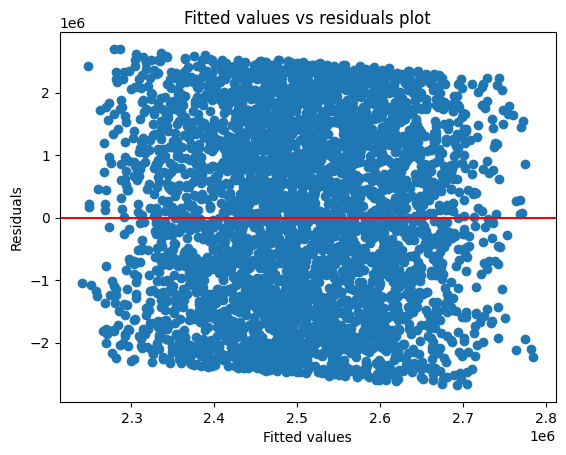

In [16]:
plt.scatter(model.predict(df_train), model.resid)
plt.axhline(y=0, color = "r", linestyle = "-")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Fitted values vs residuals plot")
plt.show()

### **Linear Regression Model Strength / Assumption Test 2: QQ plot**

The QQ Plot shown above has a S-Curve, meaning our residuals are not normally distributed. This means the normality assumption is not met. Because the normality assumption is not met, this impacts the validity of our inference results, like the confidence interval we analyzed and the hypothesis tests we formalized from our model summary. Additionally, this also means the hypothesis test we have conducted above is not very reliable.

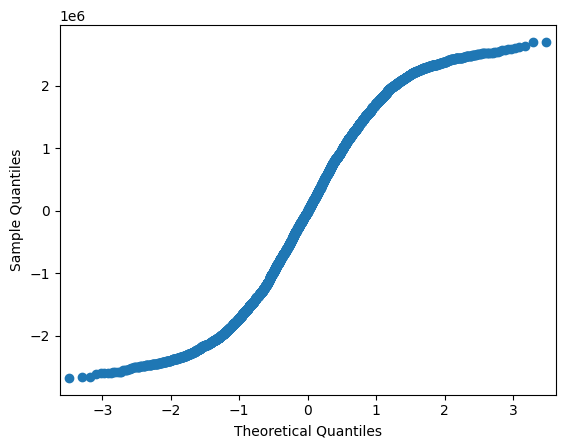

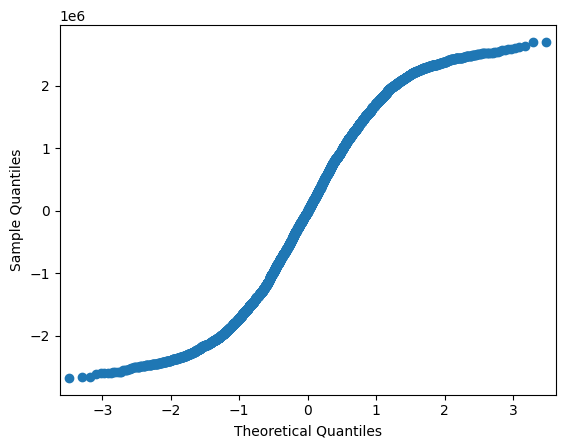

In [17]:
sm.qqplot(model.resid)

## **Model Performance Overall**

We will look at the R<sup>2</sup> for this model, as well as the RMSE to analyze how well our model performs. These two measures will provide a basis on both:

- **R<sup>2</sup> :** The variability of the number of views of a social media post that is explained by this linear model.
- **RMSE:** The typical distance the actual view count falls from the view count we predict from our linear model.

In [18]:
model.summary()

from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(df_train["Views"], model.predict(df_train))

1456354.159485541

In [19]:
prediction = model.predict(df_test) #Creating our y(hat)
df_test['Predicted_Views'] = prediction #Setting it to a column in our df_test
df_test['Predicted_Views'].astype(int) #Making all of those values integers, because we do not want float values of views

from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(df_test["Views"], df_test["Predicted_Views"])

1461537.3265122697

### **R<sup>2</sup> Interpretation:**

The R<sup>2</sup> from the training model is 0.005, or 0.5%, which is **EXTREMELY** low. This means the model explains only 0.5% of the variability within the response variable, meaning almost nothing can be explained. This suggests that the predictors do not effectively predict the patterns within the data, and the model has poor explanatory power, which contributes to our conclusion of the model being inappropriate given the context of the problem.

### **RMSE Interpretation:**
Additionally, the **RMSE** on the test data is relatively high, which is about 1,461,537. This means that the model's predictions are not very accurate and that the model likely does not generalize well to new data. In conclusion, the model does not effectively predict the number of views.

### Based off of our research, we came to the conclusion that this linear regression model **IS NOT** appropriate. 

## **3. Logistic Regression**

## **Research Question:**
### How does the platform one posts on, region one posts from, content type of a post, and the number of views, comments, likes, and shares affect the log-odds of a post having high engagement?

#### **Preparing dataset for logistic regression**

In [20]:
df["HighEngagement"] = 1*(df["Engagement_Level"] == "High")
df.head()
df_train, df_test = train_test_split(df, test_size = 0.2, random_state = 5)
#creating new logical variable, which represents a post having high engagement or not.
len(df[df["HighEngagement"] == 1])

1673

#### **Creating and fitting a logistic model, where our response variable is whether a post has high engagement (1 or 0), using the platform, region, content type, views, comments, shares, and likes predictors.**

In [21]:
results = smf.logit("HighEngagement~Platform+Region+Content_Type+Views+Comments+Likes+Shares", df_train).fit()
results.summary()

Optimization terminated successfully.
         Current function value: 0.636484
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         HighEngagement   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3980
Method:                           MLE   Df Model:                           19
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                0.004240
Time:                        15:30:43   Log-Likelihood:                -2545.9
converged:                       True   LL-Null:                       -2556.8
Covariance Type:            nonrobust   LLR p-value:                    0.3003
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0.6844      0.177     -3.859      0.000      -1.032      -0.337
Platform[T.TikTok]         0.1201      0.097      1.244      0.213      -0.069       0.309
Platform[T.Twitter]        0.2053      0.096      2.138      0.033       0.017       0.393
Platform[T.YouTube]        0.1257      0.096      1.316      0.188      -0.061       0.313
Region[T.Brazil]           0.0396      0.135      0.294      0.769      -0.225       0.304
Region[T.Canada]          -0.0320      0.134     -0.238      0.812      -0.295       0.231
Region[T.Germany]          0.1549      0.138      1.120      0.263      -0.116       0.426
Region[T.India]            0.1127      0.136      0.831      0.406      -0.153       0.379
Region[T.Japan]            0.0296      0.138      0.215      0.830      -0.240       0.300
Region[T.UK]              -0.0503      0.135     -0.373      0.709      -0.315       0.214
Region[T.USA]              0.2084      0.132      1.575      0.115      -0.051       0.468
Content_Type[T.Post]      -0.1097      0.115     -0.953      0.341      -0.335       0.116
Content_Type[T.Reel]      -0.0175      0.114     -0.153      0.878      -0.242       0.207
Content_Type[T.Shorts]    -0.1062      0.117     -0.906      0.365      -0.336       0.124
Content_Type[T.Tweet]     -0.0391      0.114     -0.342      0.732      -0.263       0.185
Content_Type[T.Video]      0.0556      0.115      0.483      0.629      -0.170       0.281
Views                  -4.586e-08    2.3e-08     -1.990      0.047    -9.1e-08   -6.99e-10
Comments               -2.507e-06   2.34e-06     -1.071      0.284    -7.1e-06    2.08e-06
Likes                  -1.839e-07   2.33e-07     -0.790      0.429    -6.4e-07    2.72e-07
Shares                   1.88e-06   1.16e-06      1.616      0.106      -4e-07    4.16e-06
==========================================================================================
"""

### **Coefficient Rundown:**

As you can see from our model summary, it is clear that there are some predictors that are associated with higher log odds of a post having high engagement, or not having high engagement. For example, we see that as far as our predictors go, here is the rundown.
- For the views predictor, specifically for this model, it looks like a high number of views would **VERY SLIGHTLY** decrease the log odds of a post having high engagement, which is definitely unexpected, because most people would think that a higher view count equates to more engagement.
- For the likes predictor, we see that a high number of likes would **VERY SLIGHTLY** decrease our log odds.
- For the comments variable, we see the same effect, that a large number of comments would **VERY, VERY SLIGHTLY** decrease our log odds.
- For the shares predictor, we see that a high number of shares **VERY SLIGHTLY** increases our log odds.
- For the content_type variable, it looks like a Reel is most associated with a high log odds of a post having high engagement.
- For the region variale, we see that posts from Germany, UK, and the US, are all associated with larger log odds of having high engagement.
- For the platform variable, it looks like posts on Tiktok have the highest coefficient out of the other platforms in this mode, so TikTok posts are most associated with having larger log odds of high engagement.

### **Model Strength:**

- **McFadden's Pseudo-R<sup>2</sup>:**   .00424 (VERY WEAK model, despite the use of all our predictors)
- **AUC:** Area under curve of ROC curve is .5, which is realistically very bad for a classifier, and therefore shows that our model **DID NOT** perform well, despite the use of almost all predictors in our dataset.


### **Creating ROC curve as well as AUC (area under ROC curve).**

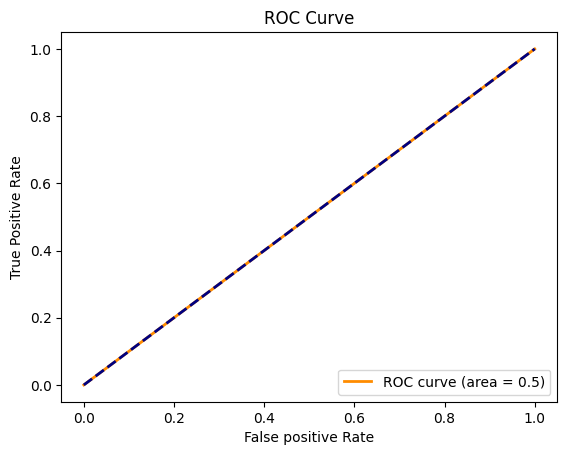

In [22]:
df_train["probs"] = results.predict(df_train)
df_train["predictions"] = 1 * (df_train["probs"]>=.5)

from sklearn.metrics import roc_auc_score, roc_curve

fprs, tprs, thresholds = roc_curve(y_true = df_train["HighEngagement"], y_score = df_train["predictions"])
auc = roc_auc_score(df_train["HighEngagement"], df_train["predictions"])

def plot_roc(fpr, tpr, auc, lw = 2):
    plt.plot(fpr, tpr, color = "darkorange", lw = lw, label = f"ROC curve (area = {auc})")
    plt.plot([0,1], [0,1], color = "navy", lw = lw, linestyle = "--")
    plt.xlabel("False positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc = "lower right")
    plt.show()

plot_roc(fprs, tprs, auc)


### **Creating a confusion matrix based on our classifier with a predictive probability threshold of .5.**

In [23]:
df_test["probs"] = results.predict(df_test)
df_test["predictions"] = 1 * (df_test["probs"]>=.5)

pd.crosstab(df_test["HighEngagement"], df_test["predictions"]) #Creating a confusion matrix between actual values, and predictions from classifier

predictions,0
HighEngagement,
0,676
1,324


### **Confusion Matrix Results on test data:**

- Accuracy Rate: 676/1000 = 67.6%  
- Sensitivity: 0 / 324 = 0%
- Specificity: 676 / 676 = 100%
- False Positive Rate: 0 / 1000 = 0%


If we were to minimize one error, we would probably want to minimize **false positives.** Suppose an influencer uses our classifier, and sees that according to our classifier, his content has high engagement. So he continues using the same platform, hashtags, content type, etc, but the entire time, the classifier has been feeding him a false positive. This would cause him to perpetuate and contiunue pushing out the content he believes is getting high engagement, but is actually not. So this is probably the error we would want to avoid.

Given that we want to **MINIMIZE** the false positive rate, and our model's false positive rate is 0 percent, it seems like a good thing on the surface. But I do not think that this is truly representative of the accuracy of our classifier, and it seems that for some reason, our classifier predicted ALL posts to not have a high engagement rate. So in reality, though our results show that we are minimizing that error in our classifier, I do not think we can trust those results given how weak our model is, unfortunately.

### **All in all, numerical and graphical measures of model strength show our logistic model did not perform well.**


## **4. Conclusion**

### **Summarizing our findings:**

We first started by cleaning our dataset, and seeing if there was anything that was necessary to be dropped ahead of our analysis. We did this by checking the types of each column, seeing how many values were n/a, etc.

### **Linear model summary:**

We then started with our linear model, in which we attempted to create and fit a model that predicts the expected number of views a social media post receives given the number of shares, likes, comments, region, and content type. After we used model strength measures and assumption testers, like the model's R<sup>2</sup>, RMSE, fitted vs. residual plot, and QQ plot, we concluded that the linear model did not perform well AND did not meet the necessary assumptions of normality.

### **Logistic model summary:**

We also created and fitted a logistic regression model to predict the expected log-odds of a social media post having high engagement given the post's number of likes, comments, shares, views, region, content type, platform predictors. According to certain measures of model strength for logistic models, like our ROC curve and its AUC, the R<sup>2</sup>, accuracy rates from our confusion matrix, it led us to believe that this logistic model performance is not good, and it does not perform well.

### **Limitations throughout our Project 3:**

Some limitations we had when doing our data analysis and our interpretations of our results would probably include the presence of slight implicit multicollinearity within our variables. For example, while fitting our models, we thought that the shares, views, likes, and comments predictors were an example of multicollinearity, given that it is obvious that an increase in one of these variables almost always signifies an increase in the other variables. So not only would this somewhat hinder our analysis, but it could definitely cloud the coefficient interpretations.

Also, the results of our confusion matrix from our logistic model's classifier somewhat limited our ability to come up with the error that should be minimized, and whether our classifier met those requirements. Our classifier classified EVERY post to NOT have high engagement, which made it quite difficult to formalize our findings in that section.

All of these limitations we have mentioned might make it hard for someone who is planning to utilize our work to rely on the predictive analyses that we created, so using model regularization or different forms of model selection is what I would recommend to maximize model accuracy!

### **Using our work and moving forward:**

If we or someone else were to use these analyses in future work, then those research questions might entail choosing different variables to analyze their relationship, or possibly delve deeper into creating predictive models by using ridge regression, a Lasso model, or some other regularized regression models using the foundations we have provided in our analyses. They can also use real world events or trends to predict why a certain platform or content type yields a certain relationship to either the views, shares, comments, or likes in a social media post. 